<a href="https://colab.research.google.com/github/Ambaright/ST-554-Homework-5/blob/main/Baright_HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Author: Amanda Baright

Date: 03.03.2026

Purpose: ST 554 Homework 5

# Part I: Concepts

## Question 1: Five V's of Big Data

**We discussed the “Five V’s of Big Data”. Give an example of a place where you’ve encountered big data or a topic you are interested in where big data would arise. Specifically address the five V’s for the example and whether/how they apply to your example.**

This past summer, I had the opportunity to complete a summer internship at Humacyte as a Biometrics and Clinical Data Management Intern. This opportunity gave me a ton of experience working with big data and the "Five V's of Big Data". During the internship, I worked on a capstone project focused on analyzing the patient-reported outcomes from two questionnaires that were being administered during the clinical trial. The clinical trial specifically focused on investigating the length of catheter-free days a patient experienced while undergoing Hemodialysis for two treatment groups: one with the gold standard ATF fistula and one with Humacyte's product, the ATEV, a bioengineered blood vessel. Below, I'll discuss how I encountered each of the five V's over the course of this capstone project.

- Volume: Given that this is a clinical trial, a large number of patients were being enrolled into the trial. While working on the project, the clinical trial had enrolled around 150 patients. However, with the focus on the questionnaires, each patient had to complete the two questionnaires within a standard amount of time during the trial. This led to a repeated measures approach for the data analysis, which meant even more data to analyze.

- Variety: For the questionnaires, the data that was collected included the patient response for Likert Scale questions on their overall health and well-being, as well as questions related to their vascular access points (ATF vs ATEV). Additionally, the sites recorded who filled out the questionnaire (patient, caregiver, or site personnel). The two types of data collected from the questionnaire provided me with some variety. Additionally, when it came to analyzing the data, I had to score the questionnaires based on the standardized procedure. Thus, creating numeric variables that can be analyzed. I also took in additional information from other data sources in the clinical database, such as age, race, gender, etc.

- Value: One of the exciting parts about this project was the fact that I was the first person in the company to begin analyzing and investigating the data we were gathering from these two questionnaires. I was able to report on my findings directly to the clinical department, the Chief Medical Officer, and the CEO. While I can't say what I found specifically, I can share that the value from the data collected helped shape the next steps for the entire clinical department regarding these two questionnaires.

- Velocity: As this was an ongoing clinical trial, databases were updated weekly as patients enrolled or reached new time points requiring questionnaire completion. After analyzing the initial data, I reran my code with revised datasets from the programming team to track metric improvements.

- Veracity: Another component of this project was to examine inconsistencies or uncertainty in the collected data. This involved identifying outliers within repeated measures for each patient and determining which questions were most frequently missed. This aspect connects with the value component, as identifying frequently missed questions enabled the clinical team to assess if additional training was needed at the sites for administering the questionnaires.

## Question 2: CRUD acronym

**Read about the database we’ll use below (part IV). Give an example for each letter in the `CRUD` acronym in the context of this database.**

## Question 3: HAVING clause in SQL

**What is the purpose of the `HAVING` clause when writing SQL code? (Recall the sqlitetutorial.net tutorial on the `SELECT` statement.)**

# Part II: Simulation of a Sampling Distribution

We looked at using simulation to investigate the sampling distribution of pˆ in the notes. We’ll now look at the sampling distribution of the sample slope from an SLR model using simulation.

Recall we assume the following model for SLR:

Yi = β0 + β1xi + Ei

where the Ei are assumed to be indendent and identically distributed from a Normal distribution with mean 0 and variance σ^2. Let’s assume σ^2 = 1 for simplicity.

We can generate data from this model by assuming values for β0, β1, and n, along with a sequence of x values via the following code:

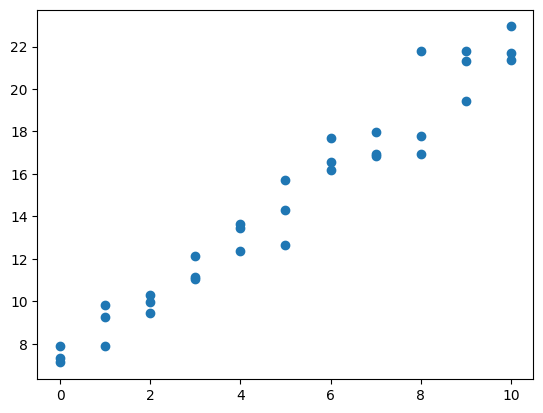

In [1]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = 33
#create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1*x + rng.standard_normal(n)
#visualize the data
plt.scatter(x = x, y = y)
plt.show()

## Part A: 5000 simulations
Now we can use `sklearn` to obtain the estimate for the slope (and save that value) as we did earlier in the course.

We will repeat the above process 5000 times. To be specific:
- Generate the y values using the code with `rng.standard_normal()`

- Find the ‘best’ slope via `sklearn`

- Save that slope in some object

In [8]:
# import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn.linear_model import LinearRegression

# set seed for random number generator
rng = default_rng(32)

# use the values specified in the above code
beta_0 = 7
beta_1 = 1.5
n = 33
iterations = 5000

# Fixed x values as per the original set up
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)

# List to store our simulated slopes
slopes = []

for i in range(iterations):
    # Generate y with standard normal random noise
    y = beta_0 + beta_1 * x + rng.standard_normal(n)

    # Fit the model
    reg = LinearRegression()
    # Here, we need to reshape x so that it has 1 column
    reg.fit(x.reshape(-1,1), y)

    # Save the slope (beta_1_hat)
    slopes.append(reg.coef_[0])

# Convert to numpy array for easier calculation
slopes = np.array(slopes)
print(slopes)

[1.47450564 1.45280552 1.53315358 ... 1.46119866 1.5023274  1.50048984]


## Part B: Histogram of Sample Slopes
We can use the many values of the sample slope as an approximation to the sampling distribution of the sample slope! Here we can create a histogram of the sample slope values we found. As we may expect, there is a normal distribution around the true slope of 1.5.

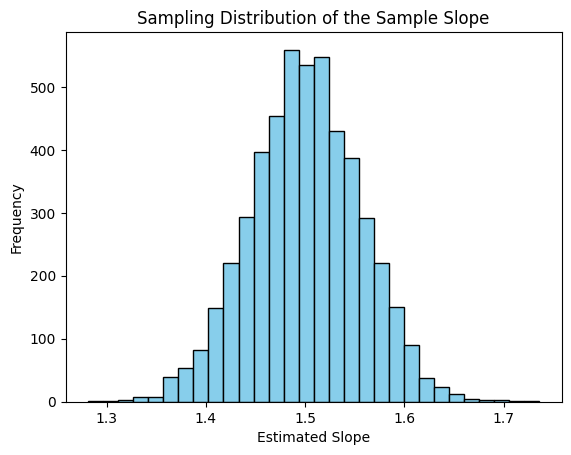

In [15]:
plt.hist(slopes, bins=30, color='skyblue', edgecolor='black')
plt.title("Sampling Distribution of the Sample Slope")
plt.xlabel("Estimated Slope")
plt.ylabel("Frequency")
plt.show()

## Part C: Probability Calculation
We can then use this sampling distribution to approximate the probability of observing a sample slope larger than 1.65. This can be done by looking at the proportion of simulated values larger than 1.65. Here we can use Boolean logic to determine which estimated slopes are larger than 1.65, if they're larger then the expression is evaluated as `True`. Since `True` values are treated as a value of 1 in Python, we can then take the average of this array to get the proportion of simulated values larger than 1.65. We find that the probability of observing a slope larger than 1.65 is 0.0038.

In [16]:
prob_larger = np.mean(slopes > 1.65)
print(f"Probability of observing a slope > 1.65: {prob_larger:.4f}")

Probability of observing a slope > 1.65: 0.0038


## Part D: Interpretation
As mentioned, we found that the probability of observing a sample slope of 1.65 or larger purely by random chance is 0.0038.

One way we can use this probability is to test the null hypothesis, Ho: $\beta_1 = 0$. If we assume that under the null hypothesis that the true slope was zero, then our simulation showed that getting a slope of 1.65 or larger has a probability of 0.0038, which is quite rare. Thus, using an alpha level of 0.05, we would reject this null hypothesis and conclude that we don't have enough statistically significant evidence that the slope is zero.

# Part III: Big Data Examples & Rare Events

## Question 5: Biases in Machine Learning Models

After reading [Biases in Machine Learning Models](https://international-review.icrc.org/articles/biases-machine-learning-big-data-analytics-ihl-implications-913), one example that was mentioned that is especially interesting is ...

Pick an example in the article and briefly outline the issue around the data used to fit the model.
(3 pts)

• Describe how we might augment the data or otherwise account for the bias in that situation. (3
pts)


## Question 6: Big Data in Earth Sciences

After reading [Big Data in Earth Sciences](https://www.science.org/doi/10.1126/science.adh9607),

Choose one of the three major areas the paper discusses. Summarize the use of big data there.
Are there any biases or other missing data that might affect results? (I know this is likely difficult
as most of us aren’t experts in Earth science - just do your best - my goal is to try to get us to
always ask questions about the data collected and used for a study!) (5 pts)

## Question 7: Understanding Rare Events

After reading [Superbolts](https://allendowney.substack.com/p/superbolts?utm_source=substack&utm_medium=email),

Mostly I just want you to read this article to understand some ways in which rare events, and
statisticians, play a role in different places. To have something to put here, can you think of
another variable or scenario where understanding rare events is important? (3 pts)


# Part IV: Querying a database

There is a database file on the assignment link called Lahman.db that is an sqlite database downloaded from [here](https://github.com/jknecht/baseball-archive-sqlite). This database has information on Major League Baseball.
